In [99]:
import pandas as pd


### 행-열 전치

In [100]:
df = pd.read_csv('./tuned_parameters.csv')
df_transposed = df.T
df_transposed.columns = df_transposed.iloc[0]
df_transposed.drop(df_transposed.index[0], inplace=True)
# df_transposed.drop("Unnamed: 0", axis=1, inplace=True)
df_transposed.to_csv('./tuned_parameters_temp.csv')
df_transposed = pd.read_csv('./tuned_parameters_temp.csv')
df_transposed = df_transposed.drop(["Unnamed: 0", "Accumulated Coverage"], axis=1)
df_transposed


,disable-inlining,max-memory-inhibit,klee-call-optimisation,use-construct-hash-stp,use-visitor-hash,equality-substitution,check-overshift,check-div-zero,use-branch-cache,use-independent-solver,...,array-value-ratio,search,switch-type,smtlib-display-constants,smtlib-abbreviation-mode,seed-file,sym-arg,sym-files,sym-stdin,Coverage
0,False,True,True,True,True,True,True,True,True,True,...,1.000000,random-path,internal,dec,let,1,15,1 8,8,1399
1,True,True,False,False,True,True,False,True,True,False,...,0.579563,nurs:cpicnt,simple,dec,none,8,15,2 23,8,1318
2,True,True,False,False,False,True,True,False,True,False,...,0.084122,random-state,internal,bin,let,9,20,2 1,12,1114
3,False,True,False,True,True,True,True,True,True,False,...,0.385358,random-path,llvm,hex,none,6,13,2 20,6,1055
4,False,False,True,True,True,False,False,True,True,False,...,0.921644,nurs:qc,llvm,hex,none,8,18,2 28,14,875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,True,True,False,True,True,True,True,False,True,True,...,0.209984,nurs:icnt,simple,bin,none,3,13,1 30,9,1440
2196,True,False,True,True,True,True,False,True,True,True,...,0.275574,dfs,simple,bin,none,3,24,2 17,146,1656
2197,False,True,True,True,True,False,True,True,False,True,...,0.436098,nurs:icnt,simple,bin,none,4,13,2 3,146,1766
2198,False,True,False,True,True,False,True,True,True,False,...,0.209984,dfs,simple,bin,none,4,4,2 30,4,1516


In [101]:
# 문자열 데이터만 선택
string_columns = df_transposed.select_dtypes(include=['object'])

string_columns.columns

Index(['seed-time', 'max-solver-time', 'batch-time',
       'uncovered-update-interval', 'search', 'switch-type',
       'smtlib-display-constants', 'smtlib-abbreviation-mode', 'sym-files'],
      dtype='object')

In [102]:
time = ['seed-time', 'uncovered-update-interval', 'max-solver-time', 'batch-time']
for t in time:
    df_transposed[t] = df_transposed[t].apply(lambda x: str(x).replace('s', ''))
    df_transposed[t] = pd.to_numeric(df_transposed[t], errors='coerce').astype(int)

In [103]:
# 'sym-files' 열을 공백을 기준으로 분리하고 결과를 새로운 열에 할당
df_transposed[['sym-files-1', 'sym-files-2']] = df_transposed['sym-files'].str.split(expand=True)
df_transposed['sym-files-1'] = pd.to_numeric(df_transposed['sym-files-1'], errors='coerce').astype(int)
df_transposed['sym-files-2'] = pd.to_numeric(df_transposed['sym-files-2'], errors='coerce').astype(int)

df2 = df_transposed.drop(["sym-files", "Coverage"], axis=1)
df2["Coverage"] = df_transposed["Coverage"]

In [104]:
# 문자열 데이터만 선택
string_columns = df2.select_dtypes(include=['object'])

string_columns.columns

Index(['search', 'switch-type', 'smtlib-display-constants',
       'smtlib-abbreviation-mode'],
      dtype='object')

In [106]:
df2.to_csv('./dataset.csv', index=False)

### 학습


In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# 데이터 로드
data = pd.read_csv('dataset.csv')

# 특성(X)과 타겟(y) 분리
X = data.drop(['Coverage'], axis=1)
y = data['Coverage']

# y값에 로그 변환 적용 (0값 처리를 위해 1을 더함)
y = np.log1p(y)

# 레이블 인코딩 적용
le = LabelEncoder()
categorical_columns = list(X.select_dtypes(include=['object']).columns)
for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

# 데이터 분할 (학습 데이터와 테스트 데이터)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 모델 학습
model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=1000, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 모델 평가 (로그 스케일)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error (log scale): {mse}")
print(f"R-squared score (log scale): {r2}")

# 원래 스케일로 변환하여 평가

y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

mse_original = mean_squared_error(y_test_exp, y_pred_exp)
r2_original = r2_score(y_test_exp, y_pred_exp)

print(f"\nMean squared error (original scale): {mse_original}")
print(f"R-squared score (original scale): {r2_original}")

# 특성 중요도 출력
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("\nTop 10 important features:")
print(feature_importance.head(10)) 

Mean squared error (log scale): 0.46593721687554895
R-squared score (log scale): 0.6416263361225079

Mean squared error (original scale): 89419.86237531359
R-squared score (original scale): 0.5544265308893714

Top 10 important features:
                     feature  importance
53               switch-type    0.499697
29            disable-verify    0.120627
2     klee-call-optimisation    0.060157
0           disable-inlining    0.036548
56                 seed-file    0.034693
34               verify-each    0.032251
6            check-overshift    0.026455
55  smtlib-abbreviation-mode    0.021432
26         cex-cache-try-all    0.014190
4           use-visitor-hash    0.010439


/opt/anaconda3/envs/swt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PermutationExplainer explainer: 2201it [01:12, 26.35it/s]                          


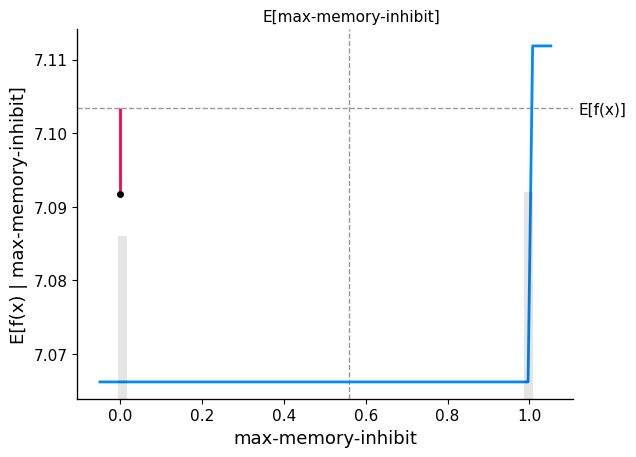

In [108]:
import shap
import numpy as np

# 데이터를 float32 타입으로 변환
X = X.astype(np.float32)

# 모델 예측 함수를 래핑
def model_predict(X):
    return model.predict(X).astype(np.float64)

# compute the SHAP values for the linear model
X100 = shap.utils.sample(X, 100)  # 100 instances for use as the background distribution
X100 = X100.astype(np.float32)

explainer = shap.Explainer(model_predict, X100)
shap_values = explainer(X)

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "max-memory-inhibit",  # "MedInc" 대신 실제 컬럼 이름 사용
    model_predict,
    X100,
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :]
)

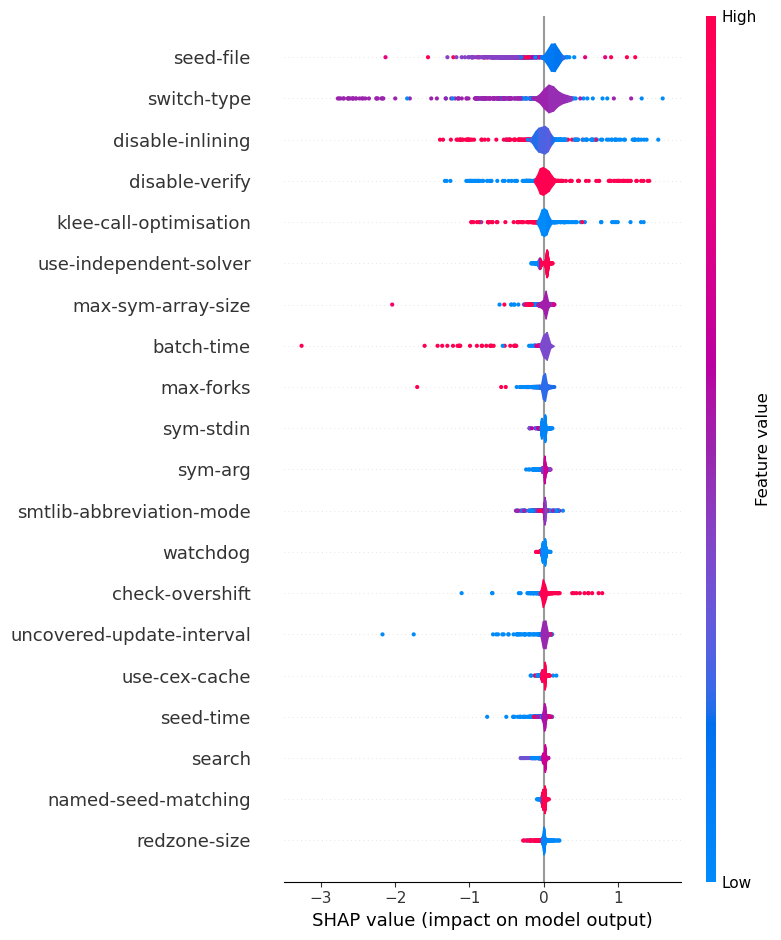

In [109]:
shap.summary_plot(shap_values, X, plot_type="violin", feature_names=X.columns)